# **Facial Expression Recognition System**

### import the dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [3]:
# os is a python library that helps interact with all the files and the folders
import os

# listdir(path)- shows everything stored inside path
print(os.listdir(path))

#train - dataset we'll use to train the model
#test - dataset we use to check how correctly the model is working

['test', 'train']


### load the training images

In [4]:
# tensorflow is a python library that helps train a model
import tensorflow as tf


#keras - a part of tensor library that is a machine learning pipeline used to train models
#.utils - a utilities or a helper function
# image_dataset_from_library - make a image datset from the directory that tensorflow can use in model trainig

train_data = tf.keras.utils.image_dataset_from_directory(

    path + "/train",
    # go to train folder in the dataset stored in path

    image_size =(48,48),

    color_mode="grayscale",

    batch_size=32
)

Found 28709 files belonging to 7 classes.


### load the testing images

In [5]:
test_data = tf.keras.utils.image_dataset_from_directory(
    path + "/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32
)

Found 7178 files belonging to 7 classes.


In [6]:
# check the data

print(test_data.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### look at what's inside train data

In [7]:
for images , labels in train_data.take(1):
  print(images.shape)
  print(labels.shape)

(32, 48, 48, 1)
(32,)


### take 9 faces from our dataset and display themin a 3*3 grid with their emotions written above their faces

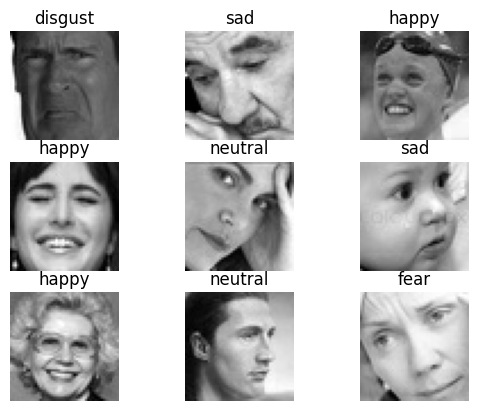

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.show()


### Normalise the numbers

In [9]:
# in grayscale the images are made of numbers ranging from 0 to 255 so we normalise it to make working easier
# we do not normalize the dataset we add a normalization layer through which every layer will go

normalisation_layer  = tf.keras.layers.Rescaling(1./255)

### CNN

In [10]:
# build an empty model using keras' sequential that makes a model layer by layer

model = tf.keras.Sequential()

In [11]:
# now we start filling the model

model.add(normalisation_layer)

# now an image enters so it becomes 48*48 then rescaling then value comes between 0-1 and then it is added to the model

In [12]:
# we use layers to access the kera layer Conv2D that is Convolutional Layer i.e. actual CNN
# in CNN model we add 32 filters ... suppose filter 1 will check the edge filter 2 will detect something else
# we do not fix the filters the model decides it itself while trainig
# the filters in our model are 32 and 3 rows 3 columns each filter format

model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu"))

In [13]:
## Convo2D finds features so now we have huge imformation . to shorten it and keep the strongest parts we use MaxPooling

model.add(tf.keras.layers.MaxPooling2D((2,2)))

In [14]:
## add another Convo2D layer to see more complex features

model.add(tf.keras.layers.Conv2D(64,(3,3),activation="relu"))

In [15]:
## add another layer of maxpooling to keep the strongest features

model.add(tf.keras.layers.MaxPooling2D((2,2)))

In [16]:
## to convert the 2*2 grid of features created by convo2D and maxpooling to a single long list

model.add(tf.keras.layers.Flatten())

In [17]:
## now we connect features to figure out the emotion using dense

model.add(tf.keras.layers.Dense(128))

In [18]:
## we want final 7 emotions so we again use dense and we want output as probabilities of getting this particular emotion so we use softmax

model.add(tf.keras.layers.Dense(7,activation="softmax"))

In [19]:
## now we have made the model but still the model doesnt know how to learn yet so .compile the model
## optimizer-adam - the mistakes that the model makes during learning how can they be improved next time
## loss - how wrong did the model learn
## accuracy - how right did the model learn

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics =["accuracy"]
)

In [21]:
## train the model using model.fit . epochs goes though the data

history = model.fit(
    train_data,
    epochs=10,
    validation_data = test_data
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 106s 118ms/step - accuracy: 0.6512 - loss: 0.9421 - val_accuracy: 0.4983 - val_loss: 1.5288
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 140s 116ms/step - accuracy: 0.6601 - loss: 0.9191 - val_accuracy: 0.4932 - val_loss: 1.5408
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 101s 112ms/step - accuracy: 0.6697 - loss: 0.8944 - val_accuracy: 0.4870 - val_loss: 1.6034
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 114ms/step - accuracy: 0.6735 - loss: 0.8823 - val_accuracy: 0.4953 - val_loss: 1.6402
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 116ms/step - accuracy: 0.6820 - loss: 0.8611 - val_accuracy: 0.4944 - val_loss: 1.6571
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 102s 113ms/step - accuracy: 0.6871 - loss: 0.8465 - val_accuracy: 0.4869 - val_loss: 1.6890
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 140s 111ms/step - accuracy: 0.6889 - loss: 0.8378 - val_accuracy: 0.4847 - val_loss: 1.7304
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 115ms/step - accuracy: 0.6954 -

In [22]:
### evaluate the model

test_loss, test_accuracy = model.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.4865 - loss: 1.8452


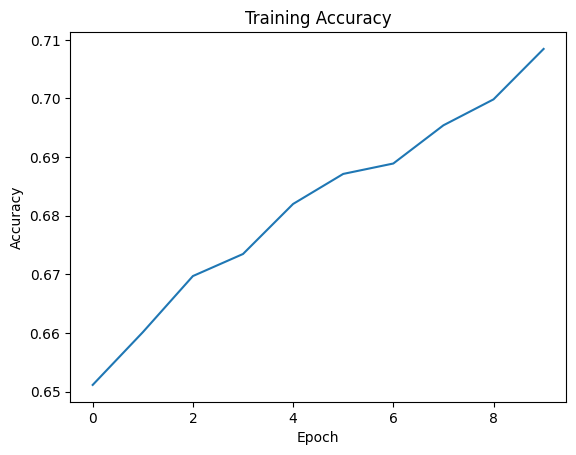

In [24]:
## plot the accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel('Accuracy')
plt.show()

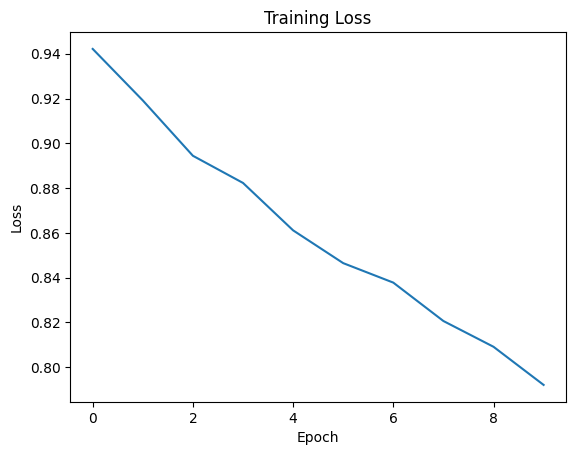

In [26]:
## loss graph

plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [28]:
## take one batch

for images,labels in test_data.take(1):
  image=images[0]
  label=labels[0]

In [29]:
## ask model to predict

prediction = model.predict(tf.expand_dims(image,axis=0))

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[2.5929552e-02 2.5688447e-03 1.9773307e-01 5.8187842e-02 6.7866027e-01
  3.6597196e-02 3.2326716e-04]]


In [31]:
predicted_class = tf.argmax(prediction[0]).numpy()
print("Predicted: ",test_data.class_names[predicted_class])

Predicted:  neutral


In [32]:
print("Actual:",test_data.class_names[label.numpy()])

Actual: sad


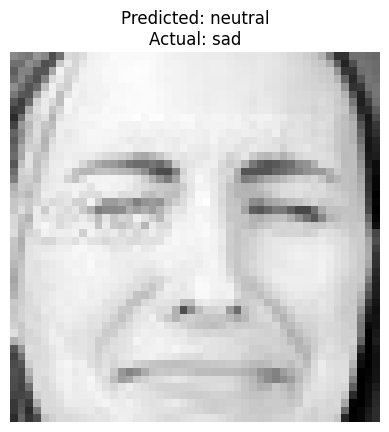

In [33]:
plt.imshow(image.numpy().squeeze(), cmap="gray")
plt.title(f"Predicted: {test_data.class_names[predicted_class]}\nActual: {test_data.class_names[label.numpy()]}")
plt.axis("off")
plt.show()

In [35]:
for images, labels in test_data.take(1):
  predictions=model.predict(images)

predicted_class= tf.argmax(predictions,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


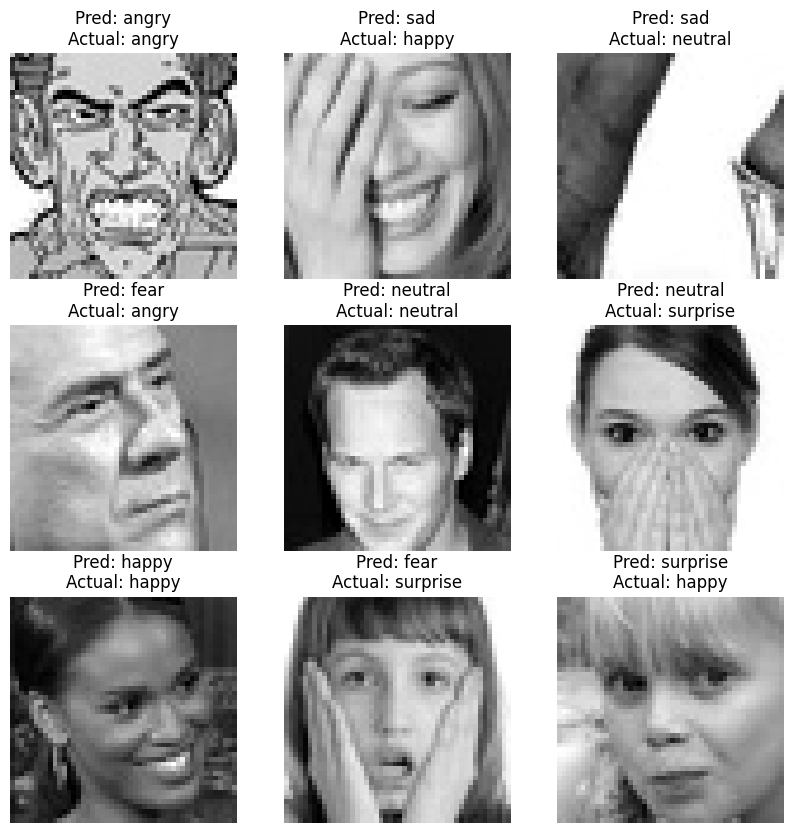

In [39]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")

    predicted = test_data.class_names[predicted_class[i]]
    actual = test_data.class_names[labels[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.show()